# 이안류 모델 시뮬레이션

`models/rip/` 아래의 이안류 탐지 모델로 `test_video/` 안의 영상 하나를 골라 탐지해본다.
아래 `VIDEO_FILENAME`에 테스트하고 싶은 파일명만 바꿔서 실행하면 된다.

In [1]:
from pathlib import Path

import cv2
from IPython.display import Video, display
from ultralytics import YOLO

In [2]:
# ==== 여기만 바꿔서 테스트 ====
VIDEO_FILENAME = "rip_current.mp4"  # test_video 안에 있는 파일명
CONF = 0.25
IOU = 0.7
IMGSZ = 640
# =============================

NOTEBOOK_DIR = Path.cwd()  # model_simulation/ 에서 실행한다고 가정
REPO_ROOT = NOTEBOOK_DIR.parent
MODEL_DIR = REPO_ROOT / "models" / "rip"
VIDEO_DIR = NOTEBOOK_DIR / "test_video"

model_candidates = sorted(MODEL_DIR.glob("*.pt")) + sorted(MODEL_DIR.glob("*.onnx"))
if not model_candidates:
    raise FileNotFoundError(f"{MODEL_DIR} 에서 모델 파일(.pt/.onnx)을 찾지 못했다")
MODEL_PATH = model_candidates[0]

video_path = VIDEO_DIR / VIDEO_FILENAME
if not video_path.exists():
    available = [p.name for p in VIDEO_DIR.glob("*")]
    raise FileNotFoundError(f"{video_path} 가 없다. test_video 안의 파일: {available}")

print(f"모델: {MODEL_PATH}")
print(f"영상: {video_path}")

모델: c:\Users\user\Documents\Daive-CV\team_beavers\models\rip\best_integrated_v2_ep70_part15.pt
영상: c:\Users\user\Documents\Daive-CV\team_beavers\model_simulation\test_video\rip_current.mp4


In [3]:
model = YOLO(str(MODEL_PATH))
print("클래스:", model.names)

클래스: {0: 'rip_current'}


In [4]:
results = model.predict(
    source=str(video_path),
    conf=CONF,
    iou=IOU,
    imgsz=IMGSZ,
    verbose=False,
)

print(f"프레임 수: {len(results)}")


WARNING  inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

프레임 수: 15337


## 프레임별 탐지 요약

In [5]:
for i, r in enumerate(results):
    n_det = len(r.boxes) if r.boxes is not None else 0
    if n_det == 0:
        continue
    classes = [model.names[int(c)] for c in r.boxes.cls.tolist()]
    confs = [round(float(c), 2) for c in r.boxes.conf.tolist()]
    print(f"frame {i}: {list(zip(classes, confs))}")

frame 0: [('rip_current', 0.35)]
frame 1: [('rip_current', 0.32)]
frame 2: [('rip_current', 0.32)]
frame 3: [('rip_current', 0.32)]
frame 4: [('rip_current', 0.32)]
frame 5: [('rip_current', 0.31)]
frame 6: [('rip_current', 0.31)]
frame 7: [('rip_current', 0.31)]
frame 8: [('rip_current', 0.32)]
frame 9: [('rip_current', 0.31)]
frame 10: [('rip_current', 0.31)]
frame 11: [('rip_current', 0.31)]
frame 12: [('rip_current', 0.32)]
frame 13: [('rip_current', 0.32)]
frame 14: [('rip_current', 0.32)]
frame 15: [('rip_current', 0.32)]
frame 16: [('rip_current', 0.32)]
frame 17: [('rip_current', 0.32)]
frame 18: [('rip_current', 0.32)]
frame 19: [('rip_current', 0.32)]
frame 20: [('rip_current', 0.32)]
frame 21: [('rip_current', 0.32)]
frame 22: [('rip_current', 0.32)]
frame 23: [('rip_current', 0.32)]
frame 24: [('rip_current', 0.32)]
frame 25: [('rip_current', 0.32)]
frame 26: [('rip_current', 0.32)]
frame 27: [('rip_current', 0.32)]
frame 28: [('rip_current', 0.32)]
frame 29: [('rip_current

## 샘플 프레임 미리보기 (탐지 있는 첫 프레임)

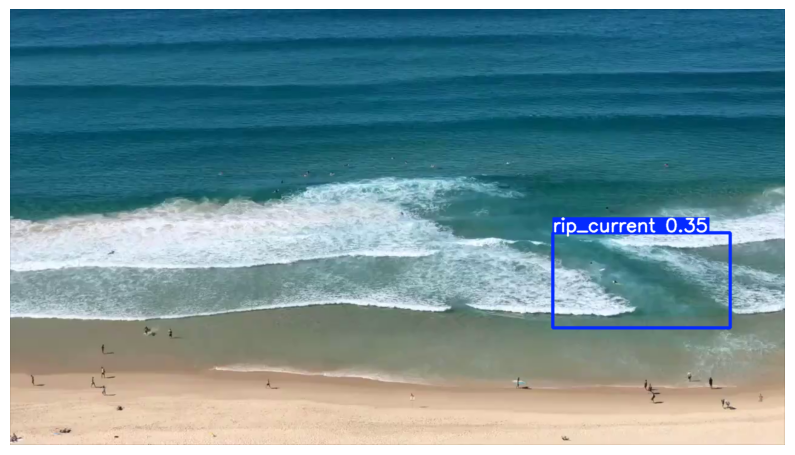

In [6]:
import matplotlib.pyplot as plt

sample = next((r for r in results if r.boxes is not None and len(r.boxes) > 0), results[0])
annotated_bgr = sample.plot()
annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(annotated_rgb)
plt.axis("off")
plt.show()

## 결과를 바로 창으로 재생하기

파일로 저장하지 않고, 방금 추론한 `results`를 그대로 OpenCV 창에 재생한다.
로컬 Windows 환경에서만 동작한다 (원격/헤드리스 서버에서는 창이 뜨지 않음).
재생 중 아무 키나 누르거나 창을 닫으면 종료된다.

In [7]:
source_cap = cv2.VideoCapture(str(video_path))
fps = source_cap.get(cv2.CAP_PROP_FPS) or 30.0
source_cap.release()
delay_ms = max(1, int(1000 / fps))

window_name = f"결과 - {video_path.name}"
cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
try:
    for r in results:
        annotated_bgr = r.plot()
        cv2.imshow(window_name, annotated_bgr)
        if cv2.waitKey(delay_ms) != -1:  # 아무 키나 누르면 중단
            break
        if cv2.getWindowProperty(window_name, cv2.WND_PROP_VISIBLE) < 1:  # 창을 닫으면 중단
            break
finally:
    cv2.destroyAllWindows()
    cv2.waitKey(1)